In [106]:
import os
from pathlib import Path
from io import StringIO


import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import scanpy as sc

In [3]:
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['svg.fonttype'] = 'none'

In [90]:
disease = 'prostate'

9551


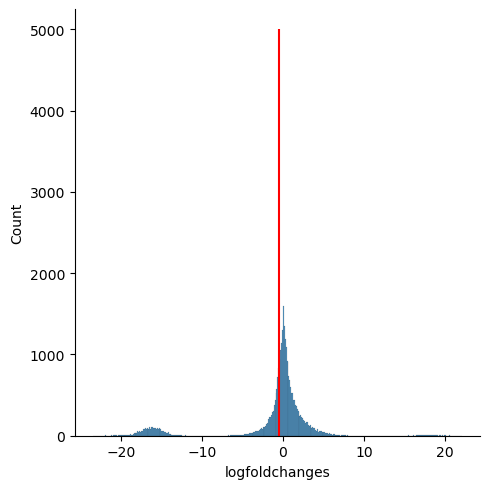

In [91]:
sc_degs = pd.read_csv(f'../data/single-cell/degs/{disease}.txt', sep='\t', index_col=0)
sc_degs

sc_lfc_cut = -.5
keep = sc_degs[sc_degs['logfoldchanges'] < sc_lfc_cut]
keep_genes = set(keep.index.to_list())
print(len(keep_genes))


sns.displot(sc_degs['logfoldchanges'])
plt.vlines(sc_lfc_cut, ymin=0, ymax=5000, colors='red', )

In [92]:
xenium_corrs = pd.read_csv(f'../data/spatial/regions/xenium/correlations_regions_caselevel_{disease}.txt', sep='\t', index_col=0)
xenium_corrs

,ABCC11,ACE2,ACKR1,ACTA2,ACTG2,ADAM28,ADAMTS1,ADGRE1,ADGRL4,ADH1C,...,RBP1,RHOD,ROBO1,SCGB1A1,SCGB3A1,SETD7,TGFBI,TIMP1,TXNIP,pks+.Escherichia.coli.clbB
case,,,,,,,,,,,,,,,,,,,,,
HT1011Z1,NaN,0.049869,NaN,-0.125221,NaN,0.099519,0.028548,0.033620,-0.034732,NaN,...,0.108179,0.101922,0.618606,0.189645,0.205680,-0.149385,-0.019232,-0.068472,0.017054,0.032711
HT814Z1,-0.044689,-0.012586,-0.017660,-0.006373,-0.000575,0.019478,-0.039153,0.009280,-0.012455,-0.024712,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HT817Z1,-0.032711,0.112135,-0.010937,-0.027948,-0.086949,0.167251,-0.158033,-0.054441,0.066803,-0.014623,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HT832Z1,0.069078,0.038412,-0.052498,0.037388,0.058757,0.206385,-0.032230,-0.014348,-0.027493,-0.023416,...,0.045534,0.065129,0.544033,0.130585,0.104574,-0.054124,0.083914,0.093728,0.185120,-0.017592
HT849Z1,-0.058295,-0.011940,0.038154,-0.015394,-0.110992,-0.007158,-0.078531,-0.057655,0.070107,0.030201,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HT852Z1,-0.045878,0.149456,-0.040740,-0.120997,-0.188174,0.000087,-0.206656,0.016290,0.058153,0.011674,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HT891Z1,0.000111,0.084955,-0.012416,0.098127,0.064370,0.158622,-0.079379,0.061667,0.040324,0.160972,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HT913Z1,-0.034743,0.067391,0.046601,0.006120,-0.119926,0.100657,-0.078305,0.053864,0.017940,0.003903,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SP003Z1,-0.031500,-0.004563,-0.002837,0.327822,0.170018,0.044462,-0.044508,-0.017189,-0.025407,-0.049501,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [93]:

xenium_source = pd.read_csv(f'../data/spatial/regions/xenium/metrics_regions_caselevel_{disease}.txt', sep='\t', index_col=0)
xenium_source.columns = [f'xenium_{c}' for c in xenium_source.columns]
xenium_source

,xenium_basal_layer_correlation,xenium_positive_passed_threshold,xenium_negative_passed_threshold,xenium_positive_passed_threshold_fraction,xenium_negative_passed_threshold_fraction,xenium_total_count
ABCC11,0.002045,1,6,0.043478,0.260870,23
ACE2,0.039579,2,1,0.083333,0.041667,24
ACKR1,-0.001104,0,3,0.000000,0.130435,23
ACTA2,0.020443,2,7,0.083333,0.291667,24
ACTG2,0.008785,5,9,0.217391,0.391304,23
...,...,...,...,...,...,...
SETD7,-0.081546,0,3,0.000000,0.750000,4
TGFBI,0.020174,0,0,0.000000,0.000000,4
TIMP1,0.069078,1,1,0.250000,0.250000,4
TXNIP,0.064098,2,1,0.500000,0.250000,4


In [94]:
cosmx_corrs = pd.read_csv(f'../data/spatial/regions/cosmx/correlations_regions_caselevel_{disease}.txt', sep='\t', index_col=0)
cosmx_corrs

,A1BG,A2M,AAAS,AAK1,AAMP,AARS1,AASS,AATK,ABAT,ABCA1,...,RPL21,RPL22,RPL32,RPL34,RPL37,RPS4Y1,SAA1/2,TPSAB1/B2,TPT1,UBA52
case,,,,,,,,,,,,,,,,,,,,,
HT891Z1,-0.004345,0.004760,0.002333,-0.002800,0.006187,-0.004256,-0.010322,-0.002481,-0.002744,-0.008225,...,-0.008027,0.013393,0.008644,0.013113,0.015093,-0.001303,0.038196,0.002147,-0.019226,0.020817
HT913Z1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.008981,NaN,NaN,...,-0.033852,-0.016124,-0.021404,-0.016866,-0.024688,-0.013975,-0.010224,-0.009128,-0.017402,-0.014900
HT935Z1,-0.017395,0.015109,0.003735,-0.011412,-0.001372,-0.008138,-0.002795,-0.013862,0.029932,-0.011156,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HT938Z1,-0.010216,-0.011255,-0.017756,-0.005889,-0.014603,0.015354,0.005204,0.008640,-0.008720,-0.014020,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HT997Z1,0.039033,0.011150,-0.002990,-0.019714,-0.003464,-0.007293,-0.023186,0.003050,0.006156,0.000038,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SP005Z1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.104135,NaN,NaN,...,0.086442,-0.026369,0.027424,-0.003532,-0.053733,-0.033604,0.102497,-0.036121,-0.049125,0.129993
SP012Z1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.020848,NaN,NaN,...,-0.023728,0.000450,-0.004325,0.001528,-0.018566,-0.040371,0.010255,-0.000640,0.035211,-0.009502


In [95]:
cosmx_source = pd.read_csv(f'../data/spatial/regions/cosmx/metrics_regions_caselevel_{disease}.txt', sep='\t', index_col=0)
cosmx_source.columns = [f'cosmx_{c}' for c in cosmx_source.columns]
cosmx_source

,cosmx_basal_layer_correlation,cosmx_positive_passed_threshold,cosmx_negative_passed_threshold,cosmx_positive_passed_threshold_fraction,cosmx_negative_passed_threshold_fraction,cosmx_total_count
A1BG,0.001769,1,0,0.25,0.00,4
A2M,0.004941,0,0,0.00,0.00,4
AAAS,-0.003669,0,0,0.00,0.00,4
AAK1,-0.009954,0,1,0.00,0.25,4
AAMP,-0.003313,0,0,0.00,0.00,4
...,...,...,...,...,...,...
RPS4Y1,-0.022314,0,2,0.00,0.50,4
SAA1/2,0.035181,2,0,0.50,0.00,4
TPSAB1/B2,-0.010936,0,1,0.00,0.25,4
TPT1,-0.012636,1,2,0.25,0.50,4


In [96]:
visiumhd_corrs = pd.read_csv(f'../data/spatial/regions/visiumhd/correlations_regions_caselevel_{disease}.txt', sep='\t', index_col=0)
visiumhd_corrs

,SAMD11,NOC2L,KLHL17,PLEKHN1,PERM1,HES4,ISG15,AGRN,RNF223,C1orf159,...,MT-ND2,MT-CO2,MT-ATP6,MT-CO3,MT-ND3,MT-ND4L,MT-ND4,MT-ND5,MT-ND6,MT-CYB
case,,,,,,,,,,,,,,,,,,,,,
HT891Z1,-0.005054,-0.029080,-0.022610,0.034495,-0.049223,-0.046194,-0.058230,0.128590,-0.012251,-0.044498,...,-0.099740,-0.147907,-0.087422,-0.100594,-0.081806,-0.045061,-0.110991,0.016671,-0.035543,-0.090404
HT935Z1,-0.016434,0.001382,-0.014886,-0.011200,-0.006287,0.010028,-0.016146,0.027569,-0.003020,-0.010813,...,-0.000459,-0.004532,0.016279,0.011851,0.012742,-0.009095,0.012125,0.055445,0.018846,0.004047


In [97]:
visiumhd_source = pd.read_csv(f'../data/spatial/regions/visiumhd/metrics_regions_caselevel_{disease}.txt', sep='\t', index_col=0)
visiumhd_source.columns = [f'visiumhd_{c}' for c in visiumhd_source.columns]
visiumhd_source


,visiumhd_basal_layer_correlation,visiumhd_positive_passed_threshold,visiumhd_negative_passed_threshold,visiumhd_positive_passed_threshold_fraction,visiumhd_negative_passed_threshold_fraction,visiumhd_total_count
SAMD11,-0.010744,0,0,0.0,0.0,2
NOC2L,-0.013849,0,0,0.0,0.0,2
KLHL17,-0.018748,0,0,0.0,0.0,2
PLEKHN1,0.011647,0,0,0.0,0.0,2
PERM1,-0.027755,0,1,0.0,0.5,2
...,...,...,...,...,...,...
MT-ND4L,-0.027078,0,1,0.0,0.5,2
MT-ND4,-0.049433,0,1,0.0,0.5,2
MT-ND5,0.036058,1,0,0.5,0.0,2
MT-ND6,-0.008349,0,0,0.0,0.0,2


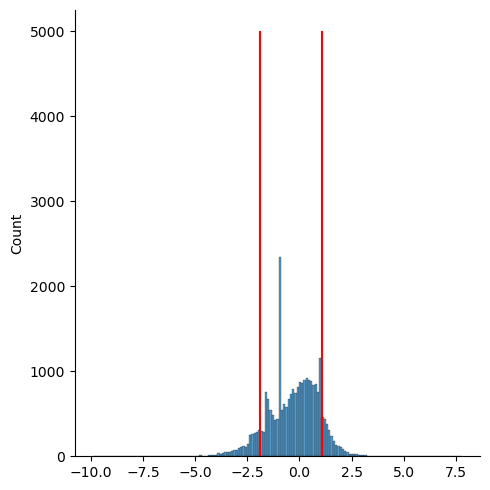

In [98]:
visium_source = pd.read_csv(f'../data/spatial/regions/visium/ttest_stat_caselevel_{disease}.txt', sep='\t', index_col=0)

arr = visium_source.values.flatten()
arr = arr[~pd.isnull(arr)]
lower, upper = np.percentile(arr, [10, 90])
xs = arr[arr>-10]
sns.displot(xs)
plt.vlines([lower, upper], ymin=0, ymax=5000, colors=['red', 'red'], )


In [99]:
visium_metrics = pd.DataFrame(visium_source.mean(0))
visium_metrics.columns = ['ttest_stat']
visium_metrics['total_count'] = (~pd.isnull(visium_source)).sum(0)
visium_metrics['positive_passed_threshold'] = (visium_source > upper).sum(0)
visium_metrics['negative_passed_threshold'] = (visium_source < lower).sum(0)
visium_metrics.columns = [f'visium_{c}' for c in visium_metrics.columns]
visium_metrics
# stat_df.to_csv(output_dir / 'ttest_stat_caselevel_prostate.txt', sep='\t')


,visium_ttest_stat,visium_total_count,visium_positive_passed_threshold,visium_negative_passed_threshold
SAMD11,-0.367332,2,0,0
NOC2L,-1.198571,2,0,0
KLHL17,0.944240,1,0,0
PLEKHN1,-0.221052,2,0,0
PERM1,NaN,0,0,0
...,...,...,...,...
KRTAP3-1,NaN,0,0,0
KRTAP10-6,NaN,0,0,0
KRTAP12-4,NaN,0,0,0
BMP15,NaN,0,0,0


In [100]:
to_values = {
    'xenium': xenium_corrs,
    'cosmx': cosmx_corrs,
    'visium': visium_source,
    'visiumhd': visiumhd_corrs
}

In [101]:

combined_source = pd.read_csv(f'../data/spatial/plots/gene_statistics_{disease}.txt', sep='\t', index_col=0)
combined_source

,xenium_basal_layer_correlation,xenium_positive_passed_threshold,xenium_negative_passed_threshold,xenium_positive_passed_threshold_fraction,xenium_negative_passed_threshold_fraction,xenium_total_count,cosmx_basal_layer_correlation,cosmx_positive_passed_threshold,cosmx_negative_passed_threshold,cosmx_positive_passed_threshold_fraction,...,visium_ttest_stat,visium_total_count,visium_positive_passed_threshold,visium_negative_passed_threshold,total_count,positive_passed_threshold,negative_passed_threshold,positive_passed_threshold_fraction,negative_passed_threshold_fraction,present_count
feature_name,,,,,,,,,,,,,,,,,,,,,
A1BG,NaN,0.0,0.0,0.0,0.0,0.0,0.001769,1.0,0.0,0.25,...,-1.000000,2.0,0.0,0.0,6.0,1.0,0.0,0.166667,0.0,1
A1BG-AS1,NaN,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.00,...,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0
A1CF,NaN,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.00,...,NaN,0.0,0.0,0.0,1.0,0.0,0.0,0.000000,0.0,1
A2M,NaN,0.0,0.0,0.0,0.0,0.0,0.004941,0.0,0.0,0.00,...,0.878449,2.0,1.0,0.0,8.0,2.0,0.0,0.250000,0.0,2
A2M-AS1,NaN,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.00,...,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZYG11B,0.022715,0.0,0.0,0.0,0.0,5.0,-0.002277,0.0,0.0,0.00,...,-0.354825,2.0,0.0,0.0,13.0,0.0,0.0,0.000000,0.0,3
ZYX,0.169991,4.0,0.0,0.8,0.0,5.0,0.002115,1.0,0.0,0.25,...,0.469453,2.0,1.0,0.0,13.0,6.0,0.0,0.461538,0.0,3
ZZEF1,NaN,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.00,...,0.638006,2.0,1.0,0.0,4.0,1.0,0.0,0.250000,0.0,2


In [102]:
value_df = combined_source[['xenium_basal_layer_correlation', 'visiumhd_basal_layer_correlation', 'visium_ttest_stat']]
value_df /= value_df.std(0)
value_df = pd.concat((value_df, combined_source[['xenium_total_count', 'visiumhd_total_count', 'visium_total_count']]), axis=1)
value_df['passes_sc'] = [x in keep_genes for x in value_df.index]

value_df

,xenium_basal_layer_correlation,visiumhd_basal_layer_correlation,visium_ttest_stat,xenium_total_count,visiumhd_total_count,visium_total_count,passes_sc
feature_name,,,,,,,
A1BG,NaN,NaN,-1.060244,0.0,0.0,2.0,False
A1BG-AS1,NaN,NaN,NaN,0.0,0.0,0.0,False
A1CF,NaN,-0.857653,NaN,0.0,1.0,0.0,True
A2M,NaN,1.422223,0.931371,0.0,2.0,2.0,False
A2M-AS1,NaN,NaN,NaN,0.0,0.0,0.0,True
...,...,...,...,...,...,...,...
ZYG11B,0.336221,0.103167,-0.376201,5.0,2.0,2.0,False
ZYX,2.516200,0.657851,0.497735,5.0,2.0,2.0,False
ZZEF1,NaN,0.333799,0.676442,0.0,2.0,2.0,False


In [103]:
to_gene_dfs = {}

In [104]:
to_gene_dfs['GDF15'] = pd.read_csv(StringIO("""Gene	Pathway role (section)
AKT1	Early cytoplasmic signalling (RET–PI3K–AKT)
BCL2	Downstream effector – survival
BCL2L1	Downstream effector – survival
CD274	Downstream effector – immune-modulatory
CDH1	Downstream effector – EMT (decreased)
CDH2	Downstream effector – EMT (increased)
ERBB2	Alternate/co-receptor (cancer)
FOS	Transcription factor
FN1	Downstream effector – motility
FOXM1	Transcription factor / IGF1R cross-talk
GFRAL	Primary receptor
GRB2	Early adaptor (RET–RAS–MAPK)
HIF1A	Transcription factor
HRAS	Early signalling (RAS–MAPK)
IGF1R	Alternate/co-receptor & cross-talk hub
IL6	Downstream effector – inflammatory
IL8	Downstream effector – angiogenesis
JAK2	Early signalling (RET–JAK/STAT)
KRAS	Early signalling (RAS–MAPK)
LOXL2	Downstream effector – invasion
MAP2K1	Early signalling (MAPK cascade)
MAP2K2	Early signalling (MAPK cascade)
MAPK1	Early signalling (MAPK cascade)
MAPK3	Early signalling (MAPK cascade)
MAPK14	Early signalling (MAPK cascade)
MMP2	Downstream effector – invasion
MMP9	Downstream effector – invasion
MTOR	Early signalling (PI3K–AKT branch)
NDRG1	Downstream effector – metastatic niche
NRAS	Early signalling (RAS–MAPK)
PIK3CA	Early signalling (PI3K catalytic subunit)
PIK3R1	Early signalling (PI3K regulatory subunit)
PPARGC1A	Downstream effector – metabolism
PTK2	IGF1R cross-talk
RAF1	Early signalling (RAS–MAPK)
RET	Primary tyrosine-kinase receptor
SHC1	Early adaptor (RET–RAS–MAPK)
SMAD2	TGF-β/SMAD branch
SMAD3	TGF-β/SMAD branch
SMAD4	TGF-β/SMAD branch
SNAI1	Transcription factor – EMT
SNAI2	Transcription factor – EMT
SOS1	Early adaptor (RET–RAS–MAPK)
SP1	Transcription factor
STAT3	Early signalling & transcription factor
TGFBR1	Alternate receptor (TGF-β type I)
TGFBR2	Alternate receptor (TGF-β type II)
TWIST1	Transcription factor – EMT
UCP1	Downstream effector – metabolism (context-specific)
VEGFA	Downstream effector – angiogenesis
VIM	Downstream effector – EMT marker
ZEB1	Transcription factor – EMT
ZEB2	Transcription factor – EMT
GDF15	Transcription factor – EMT"""), sep='\t')

to_gene_dfs['ALDH1A3'] = pd.read_csv(StringIO("""Gene	Pathway role (section)
ALDH1A1	Paralogous RA-synthetic enzyme (retinal → RA)
ALDH1A2	Paralogous RA-synthetic enzyme (retinal → RA)
CDKN1A	RA-induced cell-cycle inhibitor (p21)
CRABP1	Cytosolic RA shuttle (low-affinity)
CRABP2	Cytosolic RA shuttle (high-affinity; delivers RA to RAR)
CYP26A1	RA catabolism & negative feedback enzyme
CYP26B1	RA catabolism (extra-embryonic & cancer contexts)
CYP26C1	RA catabolism (neuro-ectoderm bias)
DUSP6	RA-induced MAPK phosphatase (differentiation)
FABP5	Alternate RA carrier, biases RA → PPARδ signalling
GATA6	RA-responsive transcription factor (endoderm / pancreatic lineage)
HES1	RA-modulated Notch effector (stemness vs. differentiation)
HOXA1	Canonical direct RA target (development & oncogenic re-activation)
HOXB1	Canonical direct RA target (posterior patterning)
HOXD4	RA-responsive homeobox gene (neural crest)
LRAT	Retinol esterification (storage buffer)
NRIP1	RA-inducible co-repressor switch (metabolic control)
RARRES1	“Retinoic-acid-receptor-responder-1”; tumour-suppressive responder
RARRES2	Chemokine-like RA responder (adipose / immune)
RARA	Nuclear RA receptor (RAR-α)
RARB	Nuclear RA receptor (RAR-β); also RA-inducible
RARG	Nuclear RA receptor (RAR-γ)
RBP1	Cellular retinol-binding protein 1 (CRBP1)
RBP2	Cellular retinol-binding protein 2 (CRBP2; intestine-biased)
RBP4	Serum retinol carrier
RDH10	Retinol → retinaldehyde oxidoreductase (rate-limiting)
RDH11	Redundant retinol dehydrogenase (adult tissues)
RDH16	Minor retinol dehydrogenase (skin / liver)
RXRA	Nuclear partner receptor (RXR-α)
RXRB	Nuclear partner receptor (RXR-β)
RXRG	Nuclear partner receptor (RXR-γ)
STRA6	Membrane receptor importing retinol-RBP4 complex
STRA8	RA-induced meiotic entry factor (germline)
ALDH1A3	"""), sep='\t')

to_gene_dfs['ANPEP'] = pd.read_csv(StringIO("""Gene	Pathway role (section)
AKT1	Survival / metabolism node in PI3K → AKT branch
ANGPT2	Pro-angiogenic effector downstream of MAPK/NF-κB
ARF6	Small-GTPase that, with IQGAP1 + EFA6, controls integrin-β1 recycling after CD13 engagement
CCL2	NF-κB-inducible chemokine recruiting pro-angiogenic myeloid cells
CYTH2	Guanine-nucleotide-exchange factor (EFA6) that activates ARF6
CXCL8	(IL-8) potent pro-angiogenic chemokine induced by NF-κB/AP-1
FERMT3	Kindlin-3; talin co-activator in inside-out integrin signalling
FN1	Fibronectin; ECM ligand whose assembly is promoted via CD13–integrin cross-talk
FOS	AP-1 transcription factor (MAPK/Src responsive)
HIF1A	Hypoxia/PI3K-AKT-responsive TF driving VEGFA, LOXL2
IL6	Autocrine/paracrine survival cytokine triggered by CD13–NF-κB
IQGAP1	Scaffold linking CD13 to ARF6–ITGB1 trafficking
ITGA5	α5 integrin subunit partnering β1 in fibronectin binding
ITGAM	αM (CD11b) subunit of CR3 integrin activated inside-out by CD13
ITGAV	αv integrin enriched in invasive/angiogenic tumors with high CD13
ITGB1	β1 integrin; trafficking modulated by CD13-IQGAP1-ARF6 axis
ITGB2	β2 (CD18) partner in CR3; activation enhanced by CD13
ITGB3	β3 integrin; co-expressed with CD13 in breast-cancer metastasis
JUN	AP-1 partner regulating IL8, MMPs
LOXL2	ECM cross-linking enzyme up-regulated by HIF1A/STAT3
MAPK1	ERK2 kinase in Src → MAPK cascade
MAPK14	p38 kinase engaged by CD13 phosphorylation
MAPK3	ERK1
MAPK8	JNK1
MMP2	Matrix-remodelling metalloprotease facilitating invasion
MMP9	Key metalloprotease that couples CD13-mediated angiogenesis/invasion
NFKB1	p50 NF-κB subunit downstream of Src/PLCγ/Syk
PIK3CA	PI3K catalytic subunit
PIK3R1	PI3K regulatory subunit
PLCG1	PLC-γ; activated by Src → Ca²⁺ signals
PTK2	FAK; integrates integrin and Src signals for migration
RAP1A	GTPase that, with Talin/Kindlin, switches integrins to high affinity
RELA	p65 NF-κB transcription factor
SRC	First tyrosine kinase activated by CD13 cross-linking
STAT3	JAK/STAT node driving VEGFA, IL6, LOXL2
SYK	Non-receptor kinase cooperating with Src/PLCγ
TLN1	Talin-1; head-to-tail with FERMT3 to activate integrins
VEGFA	Master pro-angiogenic growth factor downstream of HIF1A/NF-κB
VIM	Vimentin; EMT marker up-regulated via MAPK/NF-κB
ANPEP	"""), sep='\t')

to_gene_dfs['FASN'] = pd.read_csv(StringIO("""Gene	Pathway role (section)
ACACA	 1
ACLY	 1
ACSL4	 6
AIFM2 (FSP1)	 6
AKT1	 5
AXIN2	 3
CAV1	 4
CD274	 5 & 6
CTNNB1	 3
DGAT2	 1
EGFR	 4
ELOVL6	 1
ERBB2	 4
FADS2	 1
GPX4	 6
GRB2	 4
GSK3B	 3
HRAS	 4
INSIG1	 2
INSIG2	 2
KRAS	 4
MAP2K1	 4
MAPK1	 4
MTOR	 5
PIK3CA	 5
PORCN	 3
RICTOR	 5
RPTOR	 5
SCAP	 2
SCD	 1
SLC7A11	 6
SREBF1	 2
SREBF2	 2
WLS	 3
WNT3A	 3
FASN	"""), sep='\t')

In [66]:
to_gene_dfs['MGP'] = pd.read_csv(StringIO("""Gene	Pathway role (section)
BMP2	Pro-osteogenic ligand that MGP binds/sequesters; suppression of BMP2-Smad signaling is a key anti-calcific action of MGP 
BMP4	Second BMP family ligand neutralized by MGP to curb aberrant mineralization and vascular calcification 
BMPR1A	Type-I BMP receptor (ALK3); BMP2/4 signal through BMPR1A to drive calcification when not blocked by MGP 
ACVR1	Alternative BMP type-I receptor (ALK2) that propagates BMP2/4 cues toward osteogenic gene programs 
SMAD1	R-Smad phosphorylated downstream of BMP receptors; its activation falls when MGP restricts BMP2 binding 
SMAD5	Partner R-Smad in BMP cascades; phosphorylation rises in MGP-deficient settings 
SMAD9	(SMAD8) Third BMP-responsive R-Smad modulated alongside SMAD1/5 
SMAD4	Common-Smad that complexes with p-SMAD1/5/9 to drive transcription of osteogenic targets 
ID1	Immediate-early BMP/SMAD target whose induction marks active BMP signaling—dampened when MGP is abundant 
GGCX	γ-glutamyl carboxylase that post-translationally activates MGP (vitamin-K–dependent) 
VKORC1	Vitamin-K epoxide reductase recycling vitamin K for GGCX-mediated carboxylation of MGP 
RUNX2	Osteogenic transcription factor that binds the MGP promoter and up-regulates its expression 
SP1	Basal and PTH-responsive activator of the MGP promoter 
SP3	Competes with SP1 as a repressor, tempering MGP transcription 
VDR	Vitamin-D receptor; vitamin D signaling elevates MGP mRNA in bone and vasculature 
COL1A1	Type-I collagen subunit; its stromal expression rises via an MMP2-driven axis in MGP-high tumors 
FN1	Fibronectin; MGP binds FN1 and enhances cell adhesion/spreading on FN-rich matrices 
MMP2	Matrix metalloproteinase that reinforces collagen-rich stroma and metastasis in contexts with elevated MGP/ECM remodeling 
SPP1	Osteopontin; up-regulated in arteries and tumors when MGP activity is lost, linking to calcification and invasion
MGP	"""), sep='\t')

to_gene_dfs['PLAT'] = pd.read_csv(StringIO("""Gene	Pathway role (section)
PLG	Zymogen substrate that PLAT cleaves to plasmin, initiating fibrin and ECM proteolysis 
PLAU	Paralogous urokinase-type plasminogen activator that amplifies plasmin generation alongside PLAT 
PLAUR	Cell-surface uPA receptor; anchors plasminogen activation at the membrane and cooperates with PLAT-driven fibrinolysis 
SERPINE1	PAI-1—principal fast-binding inhibitor of PLAT/PLAU; forms complexes cleared via LRP1 
SERPINB2	PAI-2—secondary inhibitor of PLAT/PLAU that rises in inflammation / pregnancy 
SERPINF2	α-2-Antiplasmin; rapid plasmin inhibitor that stabilizes clots against PLAT-mediated lysis 
LRP1	Endocytic/scavenger receptor that binds free PLAT and PLAT–PAI-1 complexes, mediating clearance and signalling 
F13A1	Transglutaminase (FXIII-A) that cross-links α-2-antiplasmin to fibrin, making the network PLAT-resistant 
F2	Thrombin—generates fibrin substrate and activates FXIII before PLAT acts; also forms the thrombin–thrombomodulin complex that modulates CPB2 
FGA	Fibrinogen α chain; incorporated into fibrin mesh that plasmin (from PLAT) degrades 
FGB	Fibrinogen β chain; as above 
FGG	Fibrinogen γ chain; as above 
CPB2	Thrombin-activatable fibrinolysis inhibitor (TAFI); removes C-terminal Lys from fibrin, slowing PLAT-dependent plasminogen activation 
KLKB1	Plasma kallikrein; can directly convert plasminogen to plasmin and activates Factor XII, feeding into PLAT-linked fibrinolysis 
F12	Factor XIIa (contact pathway protease) that augments plasmin generation and modulates clot structure with PLAT present 
MMP9	Gelatinase activated downstream of plasmin; cooperates with the PLAT–plasmin cascade in matrix remodelling and invasion 
MMP2	Constitutive gelatinase whose activation by plasmin facilitates ECM degradation during PLAT-driven fibrinolysis 
THBD	Endothelial thrombomodulin; its complex with thrombin boosts CPB2 activation, linking coagulation to PLAT-regulated fibrinolysis 
PLAT	"""), sep='\t')


In [88]:
gene = 'GDF15'
f = value_df.loc[[g for g in to_gene_dfs[gene]['Gene'] if g in value_df.index]]
f.sort_values('xenium_basal_layer_correlation')

,xenium_basal_layer_correlation,visiumhd_basal_layer_correlation,visium_ttest_stat,xenium_total_count,visiumhd_total_count,visium_total_count,passes_sc
feature_name,,,,,,,
NDRG1,-2.348205,1.915993,-0.573226,8.0,2.0,2.0,True
AKT1,-2.271696,-1.755864,0.695115,5.0,2.0,2.0,True
TWIST1,-2.000897,-1.203328,NaN,5.0,2.0,0.0,True
MAP2K1,-1.633840,-0.343838,-0.838359,5.0,2.0,2.0,True
MTOR,-1.477673,-1.521392,1.747941,5.0,2.0,2.0,True
GDF15,-1.368192,-2.829874,-2.916558,24.0,2.0,2.0,True
CDH1,-0.882451,1.546324,-0.543450,13.0,2.0,2.0,False
ZEB1,-0.736073,0.149383,0.135986,5.0,2.0,2.0,False
HIF1A,-0.676744,-0.549447,0.023449,23.0,2.0,2.0,False


In [87]:
gene = 'ALDH1A3'
f = value_df.loc[[g for g in to_gene_dfs[gene]['Gene'] if g in value_df.index]]
f.sort_values('xenium_basal_layer_correlation')

,xenium_basal_layer_correlation,visiumhd_basal_layer_correlation,visium_ttest_stat,xenium_total_count,visiumhd_total_count,visium_total_count,passes_sc
feature_name,,,,,,,
ALDH1A3,-4.153203,-2.501781,-3.458398,23.0,2.0,2.0,True
NRIP1,-0.294546,-1.399166,-1.749679,5.0,2.0,2.0,True
GATA6,-0.214511,-0.598818,0.413993,5.0,2.0,2.0,True
CDKN1A,1.607623,-0.989803,0.283253,23.0,2.0,2.0,False
RBP1,2.102697,0.160899,-0.178246,4.0,2.0,2.0,False
RXRA,2.151119,0.628726,0.789886,5.0,2.0,2.0,False
DUSP6,2.280298,0.086025,1.021877,5.0,2.0,2.0,False
RARB,2.644515,0.895882,0.055087,5.0,2.0,2.0,False
RARA,3.082727,-0.336476,-0.711696,5.0,2.0,2.0,False


In [86]:
gene = 'ANPEP'
f = value_df.loc[[g for g in to_gene_dfs[gene]['Gene'] if g in value_df.index]]
f.sort_values('xenium_basal_layer_correlation')

,xenium_basal_layer_correlation,visiumhd_basal_layer_correlation,visium_ttest_stat,xenium_total_count,visiumhd_total_count,visium_total_count,passes_sc
feature_name,,,,,,,
AKT1,-2.271696,-1.755864,0.695115,5.0,2.0,2.0,True
ARF6,-1.609864,-0.127677,NaN,5.0,2.0,0.0,False
ANPEP,-1.136391,-0.902345,-1.492779,24.0,2.0,2.0,True
CYTH2,-1.088904,-0.320025,-0.216203,5.0,2.0,2.0,True
HIF1A,-0.676744,-0.549447,0.023449,23.0,2.0,2.0,False
ITGB1,-0.537833,0.865483,0.606433,4.0,2.0,2.0,False
MAPK1,-0.497828,-0.794393,0.616537,5.0,2.0,2.0,False
LOXL2,-0.327252,-0.744308,-1.639759,5.0,2.0,2.0,False
PLCG1,-0.116226,3.769569,-1.095298,5.0,2.0,2.0,False


In [105]:
gene = 'FASN'
f = value_df.loc[[g for g in to_gene_dfs[gene]['Gene'] if g in value_df.index]]
f.sort_values('xenium_basal_layer_correlation')

,xenium_basal_layer_correlation,visiumhd_basal_layer_correlation,visium_ttest_stat,xenium_total_count,visiumhd_total_count,visium_total_count,passes_sc
feature_name,,,,,,,
ACLY,-3.338895,0.747900,-0.154567,5.0,2.0,2.0,True
FASN,-2.729081,-2.214431,1.164361,5.0,2.0,2.0,True
SREBF1,-2.370622,1.528538,1.092038,13.0,2.0,2.0,True
ACACA,-2.287491,-0.997256,-1.259072,5.0,2.0,2.0,True
AKT1,-2.271696,-1.755864,0.695115,5.0,2.0,2.0,True
SCD,-2.233663,0.882030,0.200837,22.0,2.0,2.0,True
MAP2K1,-1.633840,-0.343838,-0.838359,5.0,2.0,2.0,True
MTOR,-1.477673,-1.521392,1.747941,5.0,2.0,2.0,True
SREBF2,-1.245524,1.807051,-0.888828,5.0,2.0,2.0,True


In [65]:
gene = 'MGP'
f = value_df.loc[[g for g in to_gene_dfs[gene]['Gene'] if g in value_df.index]]
f.sort_values('xenium_basal_layer_correlation')

,xenium_basal_layer_correlation,visiumhd_basal_layer_correlation,visium_ttest_stat,xenium_total_count,visiumhd_total_count,visium_total_count,passes_sc
feature_name,,,,,,,
FN1,-4.376484,-0.147534,-1.254635,2.0,2.0,7.0,False
SPP1,-0.380048,0.379832,0.451446,8.0,2.0,7.0,False
BMP2,-0.235555,1.570056,-0.160439,6.0,2.0,7.0,False
SP3,0.317916,-0.022927,0.147958,6.0,2.0,7.0,False
SMAD1,0.364942,-0.234625,-0.374000,6.0,2.0,7.0,True
BMP4,0.685389,-1.226898,0.427927,6.0,2.0,7.0,True
RUNX2,0.700441,-0.199558,-0.446815,6.0,2.0,4.0,False
VDR,0.730215,-0.002991,0.056921,6.0,2.0,7.0,False
SP1,0.906994,0.536867,0.202260,6.0,2.0,7.0,False


In [67]:
gene = 'PLAT'
f = value_df.loc[[g for g in to_gene_dfs[gene]['Gene'] if g in value_df.index]]
f.sort_values('xenium_basal_layer_correlation')

,xenium_basal_layer_correlation,visiumhd_basal_layer_correlation,visium_ttest_stat,xenium_total_count,visiumhd_total_count,visium_total_count,passes_sc
feature_name,,,,,,,
F12,-1.359422,-0.668023,0.357427,6.0,2.0,6.0,True
PLAUR,-0.849330,0.582294,-1.353400,6.0,2.0,7.0,False
THBD,-0.543652,-0.358729,-0.807289,6.0,2.0,7.0,True
F2,-0.503473,-0.329373,NaN,6.0,1.0,0.0,True
SERPINB2,-0.482521,0.535832,-0.880984,9.0,2.0,3.0,False
CPB2,-0.164066,-0.554500,-0.106803,6.0,1.0,1.0,True
SERPINF2,-0.047489,0.727705,-0.337230,6.0,2.0,6.0,False
PLG,0.000123,-0.503100,-0.757723,6.0,1.0,1.0,False
F13A1,0.131192,-1.684316,-0.909274,6.0,2.0,7.0,False


In [117]:
adata = sc.read_h5ad('../data/single-cell/breast.h5ad')
adata

AnnData object with n_obs × n_vars = 131348 × 34154
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.5', 'seurat_clusters', 'cell_type_final', 'is_cell', 'excluded_reason', 'gex_raw_reads', 'gex_mapped_reads', 'gex_conf_intergenic_reads', 'gex_conf_exonic_reads', 'gex_conf_intronic_reads', 'gex_conf_exonic_unique_reads', 'gex_conf_exonic_antisense_reads', 'gex_conf_exonic_dup_reads', 'gex_exonic_umis', 'gex_conf_intronic_unique_reads', 'gex_conf_intronic_antisense_reads', 'gex_conf_intronic_dup_reads', 'gex_intronic_umis', 'gex_conf_txomic_unique_reads', 'gex_umis_count', 'gex_genes_count', 'atac_raw_reads', 'atac_unmapped_reads', 'atac_lowmapq', 'atac_dup_reads', 'atac_chimeric_reads', 'atac_mitochondrial_reads', 'atac_fragments', 'atac_TSS_fragments', 'atac_peak_region_fragments', 'atac_peak_region_cutsites', 'percent.mt', 'nCount_ATAC', 'nFeature_ATAC', 'nCount_ATAC_MACS2', 'nFeature_ATAC_MACS2', 'pct_read_in_peaks_500

In [118]:
genes = sorted(set("""AKT1
CYTH2
LOXL2
AKT1
TGFBR1
MAP2K1
TWIST1
SMAD3
LOXL2
CDKN1A
DUSP6
CRABP1
FABP5
HOXA1
ACLY
AKT1
MAP2K1
MTOR
SLC7A11
ELOVL6
GPX4
SCAP
BMPR1A
ACVR1
MMP2
FN1
FGG
LRP1
PLAU
F13A1
MGP
PLAT""".split('\n')))


In [128]:
adata = adata[adata.obs['cell_type'] == 'Luminal/Tumor Cells', genes]


In [130]:
df = pd.DataFrame(data=adata[:, genes].X.toarray(), columns=genes)
corr = df.corr(method="pearson")
corr.sort_values('MGP')

,ACLY,ACVR1,AKT1,BMPR1A,CDKN1A,CRABP1,CYTH2,DUSP6,ELOVL6,F13A1,...,MGP,MMP2,MTOR,PLAT,PLAU,SCAP,SLC7A11,SMAD3,TGFBR1,TWIST1
TWIST1,-0.020278,0.023796,0.002057,0.031462,-0.007290,-0.004958,-0.022609,-0.002928,0.075841,-0.003572,...,-0.107317,-0.004084,0.019904,-0.030885,-0.001433,0.010211,-0.009326,-0.007277,-0.037135,1.000000
ELOVL6,0.015358,-0.001135,-0.000281,0.049094,-0.020767,-0.007882,0.000633,0.047618,1.000000,0.011684,...,-0.082014,-0.002589,0.037951,-0.021877,-0.005459,0.027513,-0.001804,-0.013843,-0.035830,0.075841
MTOR,0.020162,0.006148,0.005654,0.025772,-0.008226,-0.005811,0.021925,0.030103,0.037951,0.006622,...,-0.043992,-0.005665,1.000000,-0.010953,0.001286,0.030683,0.005633,0.007671,0.000712,0.019904
ACLY,1.000000,-0.008265,0.016991,-0.013528,0.000511,-0.008112,0.026175,0.016882,0.015358,-0.009707,...,-0.033998,-0.006315,0.020162,-0.006465,0.000009,0.014940,-0.000058,-0.008211,0.004764,-0.020278
SLC7A11,-0.000058,-0.000490,-0.000990,0.005322,-0.001165,0.000522,0.006013,0.004550,-0.001804,-0.003312,...,-0.023522,-0.000014,0.005633,0.006723,-0.004011,-0.005158,1.000000,0.004506,0.036138,-0.009326
CYTH2,0.026175,-0.007667,0.016648,-0.009299,0.009775,-0.011305,1.000000,0.022023,0.000633,-0.008185,...,-0.020628,0.000199,0.021925,0.005868,0.003599,0.008294,0.006013,0.006579,-0.001587,-0.022609
SCAP,0.014940,-0.001310,0.005913,0.017096,-0.001041,-0.008904,0.008294,0.017786,0.027513,0.010457,...,-0.014191,0.001488,0.030683,0.006053,-0.006297,1.000000,-0.005158,0.003101,-0.004915,0.010211
AKT1,0.016991,-0.016453,1.000000,-0.016552,0.002644,-0.008986,0.016648,0.000431,-0.000281,-0.000692,...,-0.008737,-0.002337,0.005654,0.013027,0.010517,0.005913,-0.000990,-0.002050,0.009201,0.002057
F13A1,-0.009707,0.009070,-0.000692,0.004392,0.008356,-0.002356,-0.008185,-0.000021,0.011684,1.000000,...,-0.003067,0.031163,0.006622,-0.002368,0.047173,0.010457,-0.003312,0.003668,0.014209,-0.003572
BMPR1A,-0.013528,0.023438,-0.016552,1.000000,-0.010010,0.016929,-0.009299,0.012063,0.049094,0.004392,...,-0.002517,0.001629,0.025772,-0.032696,-0.009231,0.017096,0.005322,0.026041,-0.002382,0.031462
